In [1]:
import skeliner as sk

In [2]:
mesh = sk.io.load_mesh("./data/720575940552805191.obj")

In [3]:
# 1. Parallel patches
patches = sk.pre.find_parallel_patches(mesh, verbose=True)
if patches:
    mesh = sk.pre.remove_parallel_patches(mesh, patches=patches, verbose=True)

[skeliner.pre] Parallel patches: 1 patches, 3 faces
  X=540666: 3f (+1 / -2)
[skeliner.pre] Parallel patches: 1 Mode A (fold), 0 Mode B (parallel)
[skeliner.pre] Removing 3 patch faces
[skeliner.pre] No newly orphaned components from removal


In [4]:
# 2. Organelles
organelles, mesh_stats = sk.pre.find_organelles(mesh, return_mesh_stats=True, verbose=True)

[skeliner.pre] Auto radius: 545.6 (5.0x median edge 109.1)
[skeliner.pre] Components: 149 total, 61 structural (>= 100 faces)
[skeliner.pre] Raw internal faces: 141,894 (31.1%)
[skeliner.pre] Isolated: 127 via outward_dots, 21 via geometric fallback
[skeliner.pre] Isolated fragments: 148 (36,266 faces), 0 external (kept)
[skeliner.pre] Structural components: main + 1 disconnected (63f)
[skeliner.pre] Rims: 132 pockets (fold >= 3.0), 25,027 mouth edges
[skeliner.pre] Pockets: 132, pocket mouth edges: 25,027, seeds: 21,007
[skeliner.pre] Pocket organelles (>= 5): 117,440 faces (initial 93,843, bridged +1, holes +24,908, rejected 17)
[skeliner.pre] Pocket organelles: 117,440 faces (main: 117,440, other: 0)
[skeliner.pre] find_organelles done: pocket=117,440, isolated=36,266 (13.4s)


[find_nucleus_center] 227,948 vertices, ~183 Z-levels
[find_nucleus_center] nucleus: center=(539313, 517150, 76818), Z=[73458,80178], peak_r=2800 nm, 33 Z-levels
[skeliner.pre] Soma: nucleus center=(539313, 517150, 76818)
[skeliner.pre] Soma: building vertex adjacency...
[skeliner.pre] Soma: BFS ring analysis...
[skeliner.pre] Soma: seed ring 0: 3200 verts (soma surface at mid-Z)
[skeliner.pre] Soma: cutoff 36 < min_cutoff 57 (z_span/avg_edge), extending
[skeliner.pre] Soma: peak ring 11, cutoff ring 57/367 (peak search limit 173)
[skeliner.pre]   soma verts: 80,532 inside ellipsoid
[skeliner.pre]   soma verts: +2,181 dilated → 82,713
[skeliner.pre]   soma verts: +52 absorbed pockets → 82,765
[skeliner.pre]   soma verts: 258 verts in 1 neurite branches preserved
[skeliner.pre]   soma verts: +1,727 disconnected → 84,492
[skeliner.pre] Soma: excluded 35,320 organelle verts → 49,172
[skeliner.pre] Soma: center=[538954, 516370, 77123], axes=[6309, 4816, 3822], 49,172 surface verts (cutoff 

(<Figure size 800x800 with 4 Axes>,
 [<Axes: title={'center': 'XY'}, xlabel='x', ylabel='y'>,
  <Axes: title={'center': 'XZ'}, xlabel='x', ylabel='z'>,
  <Axes: title={'center': 'ZY'}, xlabel='z', ylabel='y'>])

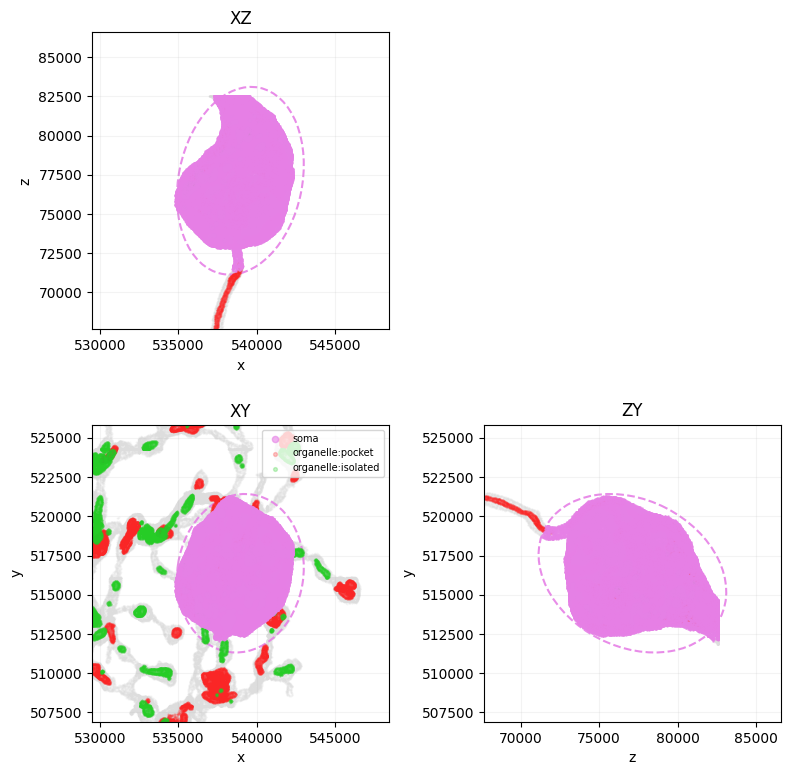

In [5]:
# 3. Soma
soma = sk.pre.find_soma_via_ring_cutoff(mesh, organelles=organelles, mesh_stats=mesh_stats, verbose=True)
sk.plot.vis2d.diagnose_soma(mesh=mesh, soma=soma, organelles=organelles, figsize=(8,8))

In [6]:
# 4. Disconnected → gaps
disconnected = sk.pre.find_disconnected(mesh, soma=soma, organelles=organelles, mesh_stats=mesh_stats, verbose=True)

gaps = sk.pre.find_gaps(mesh, soma=soma, disconnected=disconnected, mesh_stats=mesh_stats, verbose=True)
if gaps:
    mesh = sk.pre.remove_gaps(mesh, gaps=gaps, mesh_stats=mesh_stats, verbose=True)

[skeliner.pre] Disconnected: 149 total components
[skeliner.pre] Disconnected: building KDTree...
[skeliner.pre] Disconnected: 148 non-main components, 25 dropped by < 7 filter
[skeliner.pre] Disconnected: 0 components, 0 faces, 123 organelle excluded
[skeliner.pre] Gaps: 0 disconnected components


In [7]:
# 5. Fusions
fusions = sk.pre.find_fusions(mesh, mesh_stats=mesh_stats, verbose=True)
if fusions:
    mesh = sk.pre.remove_fusions(mesh, fusions=fusions, mesh_stats=mesh_stats, verbose=True)

[skeliner.pre] Mesh: 456,780 faces, 247 zero-area, 9 non-manifold edges
[skeliner.pre] Scanning 227,948 vertices for fan fusions ...
[skeliner.pre]   Fan vertex 26113: 2 components, sizes [7, 3]
[skeliner.pre]   Fan vertex 148226: 2 components, sizes [3, 2]
[skeliner.pre]   Fan vertex 183206: 2 components, sizes [7, 2]
[skeliner.pre]   Fan vertex 197700: 3 components, sizes [6, 2, 1]
[skeliner.pre]   Fan vertex 198210: 2 components, sizes [4, 2]
[skeliner.pre]   Fan vertex 208799: 2 components, sizes [6, 5]
[skeliner.pre] Fusions: scanned 227,948 vertices, 6 fan fusions found
[skeliner.pre] Fusion seeds: 5 clusters, 21 faces (nm_neg=18, dupes=6, fan_verts=6)
[skeliner.pre] Growing seed cluster 1/5 (9f) ...
[skeliner.pre]   ring 3: 46f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 4: 71f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 5: 103f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 6: 147f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 7: 195f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 8: 253f, 3 comps (1

In [8]:
# 6. Break up mesh
if soma is not None:
    components = sk.pre.break_up_mesh(mesh, soma, organelles, verbose=True)

break_up_mesh: absorbed 183 faces (140 verts) as missed soma
break_up_mesh: 1 neurites, 0 discarded (0 faces, threshold ~208589 faces), soma 49,301 verts, organelles 153,706 faces


In [9]:
# 7. Optional Mesh Compaction (remove degenerated faces and reindex everything, not truly necessary)
# mesh, components = sk.pre.compact_mesh(mesh, components=components, verbose=True)

In [10]:
# Or run the entire pipeline in one call:
mesh, components = sk.preprocess(mesh, compact=True, verbose=True)

[skeliner.pre] Parallel patches: 0 patches, 0 faces
[skeliner.pre] Auto radius: 545.6 (5.0x median edge 109.1)
[skeliner.pre] Components: 148 total, 61 structural (>= 100 faces)
[skeliner.pre] Raw internal faces: 141,875 (31.1%)
[skeliner.pre] Isolated: 127 via outward_dots, 20 via geometric fallback
[skeliner.pre] Isolated fragments: 147 (36,261 faces), 0 external (kept)
[skeliner.pre] Structural components: main + 1 disconnected (117f)
[skeliner.pre] Rims: 133 pockets (fold >= 3.0), 24,965 mouth edges
[skeliner.pre] Pockets: 133, pocket mouth edges: 24,965, seeds: 20,957
[skeliner.pre] Pocket organelles (>= 5): 117,331 faces (initial 93,761, bridged +1, holes +24,881, rejected 17)
[skeliner.pre] Pocket organelles: 117,331 faces (main: 117,331, other: 0)
[skeliner.pre] find_organelles done: pocket=117,331, isolated=36,261 (12.1s)
[find_nucleus_center] 227,953 vertices, ~183 Z-levels
[find_nucleus_center] nucleus: center=(539313, 517150, 76818), Z=[73458,80178], peak_r=2800 nm, 33 Z-le

(<Figure size 800x800 with 4 Axes>,
 [<Axes: title={'center': 'XY'}, xlabel='x', ylabel='y'>,
  <Axes: title={'center': 'XZ'}, xlabel='x', ylabel='z'>,
  <Axes: title={'center': 'ZY'}, xlabel='z', ylabel='y'>])

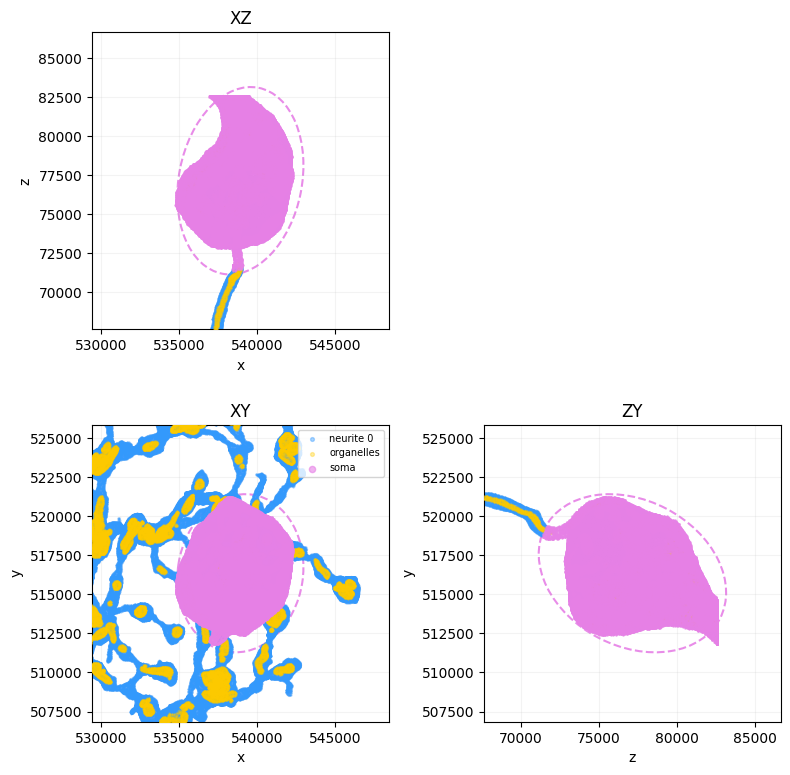

In [11]:
sk.plot.vis2d.diagnose_components(mesh=mesh, components=components, figsize=(8,8))

In [12]:
# # save mesh and components
sk.io.save_mesh(mesh=mesh, path="./data/mesh_cleaned.obj")
sk.io.save_components(components, path="./data/components.npz")


In [13]:
%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark

Last updated: 2026-04-09 15:32:59 CEST

Python implementation: CPython
Python version       : 3.13.11
IPython version      : 9.12.0

skeliner: 0.3.0

Watermark: 2.6.0

